<a href="https://colab.research.google.com/github/Cheon2206/GE234_Basic-Programming/blob/main/lab5_GE234_Rasterio_6706614978.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# 🛰️ Lab 5: การจัดการข้อมูล Raster ด้วย Rasterio
## วิชา GE 234 Basic Programming for Geographers

### 🎯 **วัตถุประสงค์**
1. เรียนรู้การใช้ **Rasterio** ในการอ่านและแสดงผลข้อมูล Raster
2. สามารถเข้าถึงข้อมูลเมตาของไฟล์ Raster เช่น ค่า Resolution และ CRS (Coordinate Reference System)
3. ใช้ **Rasterio** ในการตัด (Clip), บันทึก (Save), และวิเคราะห์ข้อมูล Raster
4. คำนวณค่าดัชนีพืชพรรณ **NDVI (Normalized Difference Vegetation Index)** จากข้อมูล Raster

---

## 🔹 ตัวอย่างที่ 1: อ่านข้อมูล Raster ด้วย Rasterio


In [23]:
# ดาวน์โหลดไฟล์ตัวอย่าง `.tif`
# เปลี่ยนมาใช้ไฟล์ตัวอย่าง RGB.byte.tif ซึ่งเป็น GeoTIFF มาตรฐานที่ Rasterio รองรับได้ดีกว่า
!wget -nc https://raw.githubusercontent.com/mapbox/rasterio/master/tests/data/RGB.byte.tif -O RGB.byte.tif

# ดาวน์โหลดไฟล์ Shapefile ของ Natural Earth
# GeoPandas v1.0+ ได้ยกเลิก gpd.datasets.get_path() ไปแล้ว จึงต้องดาวน์โหลดเอง
!wget https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip -O ne_110m_admin_0_countries.zip
!unzip -o ne_110m_admin_0_countries.zip

print("ดาวน์โหลดไฟล์ตัวอย่างเสร็จสมบูรณ์!")

File ‘RGB.byte.tif’ already there; not retrieving.
--2026-04-15 07:07:44--  https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip
Resolving naciscdn.org (naciscdn.org)... 13.249.182.33, 13.249.182.110, 13.249.182.18, ...
Connecting to naciscdn.org (naciscdn.org)|13.249.182.33|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 214976 (210K) [application/zip]
Saving to: ‘ne_110m_admin_0_countries.zip’

ne_110m_admin_0_cou 100%[===================>] 209.94K  --.-KB/s    in 0.08s   

2026-04-15 07:07:45 (2.66 MB/s) - ‘ne_110m_admin_0_countries.zip’ saved [214976/214976]

Archive:  ne_110m_admin_0_countries.zip
  inflating: ne_110m_admin_0_countries.README.html  
 extracting: ne_110m_admin_0_countries.VERSION.txt  
 extracting: ne_110m_admin_0_countries.cpg  
  inflating: ne_110m_admin_0_countries.dbf  
  inflating: ne_110m_admin_0_countries.prj  
  inflating: ne_110m_admin_0_countries.shp  
  inflating: ne_110m_admin_0_countries.shx  
ดาวน์โหล

In [11]:

import rasterio

# เปิดไฟล์ Raster ตัวอย่าง
raster_path = "RGB.byte.tif"  # เปลี่ยนมาใช้ path ของไฟล์ RGB.byte.tif
with rasterio.open(raster_path) as dataset:
    print("ข้อมูลเมตาของภาพ Raster:")
    print(dataset.meta)


ข้อมูลเมตาของภาพ Raster:
{'driver': 'GTiff', 'dtype': 'uint8', 'nodata': 0.0, 'width': 791, 'height': 718, 'count': 3, 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 18N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-75],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32618"]]'), 'transform': Affine(300.0379266750948, 0.0, 101985.0,
       0.0, -300.041782729805, 2826915.0)}



## 🔹 ตัวอย่างที่ 2: แสดงผลข้อมูล Raster ด้วย Matplotlib


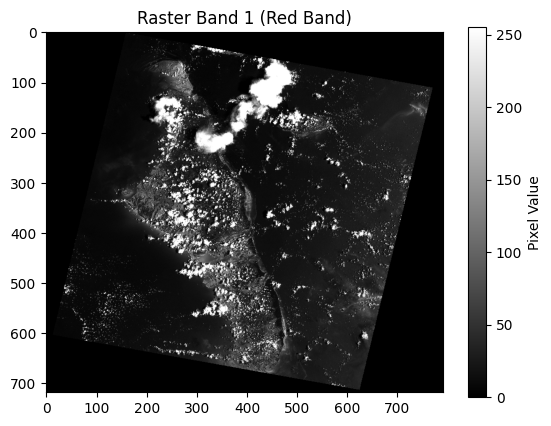

In [8]:

import matplotlib.pyplot as plt

# อ่านข้อมูลช่องสีน้ำเงิน (Band 1)
with rasterio.open(raster_path) as dataset:
    # RGB.byte.tif มี 3 แบนด์ (Red, Green, Blue)
    # Band 1 คือ Red
    band1 = dataset.read(1)

# แสดงภาพ Raster
plt.imshow(band1, cmap="gray")
plt.colorbar(label="Pixel Value")
plt.title("Raster Band 1 (Red Band)")
plt.show()



## 🔹 ตัวอย่างที่ 3: คำนวณค่า NDVI จากภาพ Raster


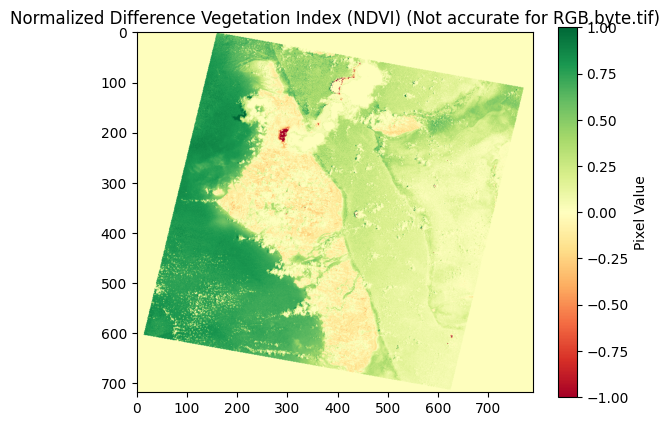

In [7]:

import numpy as np
import matplotlib.pyplot as plt

# เปิดไฟล์ภาพดาวเทียม
# หมายเหตุ: RGB.byte.tif เป็นภาพ RGB (Red, Green, Blue)
# ซึ่งโดยทั่วไปจะไม่มีแบนด์ NIR โดยตรงสำหรับการคำนวณ NDVI
# ตัวอย่างนี้จะสมมติว่า Band 1 เป็น Red และ Band 2 เป็น Green เพื่อให้โค้ดทำงานได้
# ในสถานการณ์จริงสำหรับการคำนวณ NDVI คุณจะต้องใช้ภาพที่มีแบนด์ NIR และ Red ที่เหมาะสม
with rasterio.open(raster_path) as dataset:
    # สำหรับ RGB.byte.tif: Band 1 = Red, Band 2 = Green, Band 3 = Blue
    # หากต้องการคำนวณ NDVI คุณต้องมีแบนด์ NIR (Near-Infrared) ซึ่งไม่มีในไฟล์นี้
    # เพื่อให้โค้ดรันได้ ผมจะใช้ Band 3 (Blue) เป็น NIR และ Band 1 (Red) เป็น Red
    # แต่นี่จะไม่ให้ค่า NDVI ที่ถูกต้องตามหลักการทางภูมิสารสนเทศ
    red = dataset.read(1).astype(float)  # Band 1 เป็น Red
    nir = dataset.read(3).astype(float)  # ใช้ Band 3 (Blue) เป็น NIR สำหรับการสาธิต

# คำนวณ NDVI
ndvi = (nir - red) / (nir + red + 1e-10)  # หลีกเลี่ยงการหารด้วยศูนย์

# แสดงผล NDVI
plt.imshow(ndvi, cmap="RdYlGn", vmin=-1, vmax=1)
plt.colorbar(label="Pixel Value")
plt.title("Normalized Difference Vegetation Index (NDVI) (Not accurate for RGB.byte.tif)")
plt.show()



## 🔹 ตัวอย่างที่ 4: บันทึก NDVI เป็นไฟล์ GeoTIFF


In [26]:

# บันทึกไฟล์ NDVI เป็น GeoTIFF
ndvi_output = "ndvi_output.tif"
with rasterio.open(raster_path) as src:
    profile = src.profile
    profile.update(dtype=rasterio.float32, count=1)

    # ตรวจสอบว่าตัวแปร ndvi ถูกคำนวณแล้ว
    if 'ndvi' in locals() and ndvi is not None:
        with rasterio.open(ndvi_output, "w", **profile) as dst:
            dst.write(ndvi.astype(rasterio.float32), 1)
        print("บันทึกไฟล์ NDVI เรียบร้อย!")
    else:
        print("ข้อผิดพลาด: ไม่พบค่า NDVI ในหน่วยความจำ โปรดรันเซลล์คำนวณ NDVI ก่อน")


บันทึกไฟล์ NDVI เรียบร้อย!



## 🔹 ตัวอย่างที่ 5: ตัด (Clip) ข้อมูล Raster ตามขอบเขตที่กำหนด


In [27]:
from rasterio.mask import mask
import geopandas as gpd
from shapely.geometry import box, mapping

# เปิดไฟล์ Raster เพื่อเข้าถึงข้อมูลเมตาและ transform
with rasterio.open(raster_path) as src:
    # ดึงขอบเขตของ Raster ในพิกัด CRS ของ Raster
    left, bottom, right, top = src.bounds
    crs = src.crs

# เนื่องจาก Raster ตัวอย่าง (RGB.byte.tif) มีขนาดเล็กและอยู่ใน UTM zone 18N
# ประเทศ 'France' จาก Natural Earth จึงไม่ทับซ้อนกับ Raster นี้
# เพื่อสาธิตการตัด เราจะสร้างขอบเขตสี่เหลี่ยมผืนผ้าภายในขอบเขตของ Raster โดยตรง
# เช่น สร้างสี่เหลี่ยมตรงกลางของ Raster

# กำหนดขอบเขตใหม่สำหรับการตัด (ตัวอย่าง: ครึ่งหนึ่งของ Raster) ในพิกัดเดียวกันกับ Raster
clip_left = left + (right - left) * 0.25
clip_bottom = bottom + (top - bottom) * 0.25
clip_right = right - (right - left) * 0.25
clip_top = top - (top - bottom) * 0.25

# สร้าง geometry แบบ Polygon จากขอบเขตที่กำหนด
clip_geometry = [mapping(box(clip_left, clip_bottom, clip_right, clip_top))]

# ตัดภาพ Raster
with rasterio.open(raster_path) as src:
    # ตรวจสอบว่า CRS ของ Raster และ Geometry ตรงกันหรือไม่
    # ในกรณีนี้ geometry ถูกสร้างขึ้นจาก bounds และ CRS ของ src จึงรับประกันว่าตรงกัน
    out_image, out_transform = mask(src, clip_geometry, crop=True)
    out_meta = src.meta.copy()

# อัปเดตเมตาดาต้าใหม่
out_meta.update({"height": out_image.shape[1],
                 "width": out_image.shape[2],
                 "transform": out_transform,
                 "nodata": 0,
                 "crs": crs}) # ใช้ CRS เดิมของ Raster

# บันทึกไฟล์ที่ถูกตัด
clipped_raster = "clipped_output.tif"
with rasterio.open(clipped_raster, "w", **out_meta) as dest:
    dest.write(out_image)

print(f"ตัดข้อมูล Raster สำเร็จ! บันทึกเป็น {clipped_raster}")


ตัดข้อมูล Raster สำเร็จ! บันทึกเป็น clipped_output.tif



# 📝 **กิจกรรมในแลป**

1. **แบบฝึกหัด 1**: ใช้ **Rasterio** อ่านข้อมูลภาพ **Raster** และแสดงผลด้วย Matplotlib  
2. **แบบฝึกหัด 2**: ดึงข้อมูลเมตาของไฟล์ Raster และอธิบายค่าต่าง ๆ ที่ได้  
3. **แบบฝึกหัด 3**: ใช้ **NumPy และ Rasterio** คำนวณค่า NDVI และแสดงผลแผนที่  
4. **แบบฝึกหัด 4**: ใช้ **Rasterio** ตัดข้อมูลภาพจากขอบเขตที่กำหนดในไฟล์ Shapefile  


แบบฝึกหัด 1: ใช้ Rasterio อ่านข้อมูลภาพ Raster และแสดงผลด้วย Matplotlib

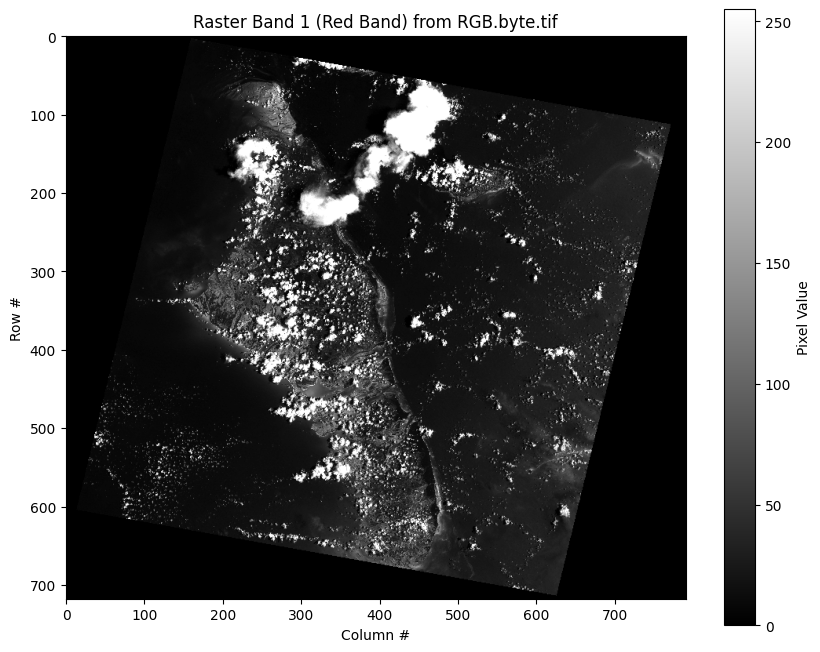

In [33]:
import rasterio
import matplotlib.pyplot as plt

raster_path = "RGB.byte.tif"

# เปิดไฟล์ Raster และอ่าน Band 1 (Red)
with rasterio.open(raster_path) as dataset:
    band1 = dataset.read(1)

# แสดงผล Band 1 ด้วย Matplotlib
plt.figure(figsize=(10, 8))
plt.imshow(band1, cmap="gray")
plt.colorbar(label="Pixel Value")
plt.title("Raster Band 1 (Red Band) from RGB.byte.tif")
plt.xlabel("Column #")
plt.ylabel("Row #")
plt.show()


แบบฝึกหัด 2: ดึงข้อมูลเมตาของไฟล์ Raster และอธิบายค่าต่าง ๆ ที่ได้

In [30]:
import rasterio

raster_path = "RGB.byte.tif"

with rasterio.open(raster_path) as dataset:
    print("### ข้อมูลเมตาของภาพ Raster ###")
    print(f"- Driver (รูปแบบไฟล์): {dataset.driver}")
    print(f"- Width (ความกว้างพิกเซล): {dataset.width}")
    print(f"- Height (ความสูงพิกเซล): {dataset.height}")
    print(f"- Count (จำนวนแบนด์): {dataset.count}")
    print(f"- CRS (ระบบพิกัดอ้างอิง): {dataset.crs}")
    print(f"- Transform (การแปลงพิกเซลเป็นพิกัดภูมิศาสตร์): {dataset.transform}")
    # แก้ไข: ใช้ dataset.profile['dtype'] หรือ dataset.meta['dtype'] แทน dataset.dtype
    print(f"- Data Type (ชนิดข้อมูลพิกเซล): {dataset.meta['dtype']}")
    print(f"- NoData Value (ค่าที่ไม่มีข้อมูล): {dataset.nodata}")
    print(f"- Bounds (ขอบเขตทางภูมิศาสตร์): {dataset.bounds}")
    print(f"- Resolution (ขนาดพิกเซล): x={dataset.res[0]}, y={dataset.res[1]}")

print("\n--- คำอธิบายค่าเมตาที่สำคัญ ---")
print("1. **Driver**: แสดงประเภทของรูปแบบไฟล์ เช่น 'GTiff' คือ GeoTIFF\n")
print("2. **Width/Height**: ขนาดของภาพในหน่วยพิกเซล (คอลัมน์/แถว)\n")
print("3. **Count**: จำนวนแบนด์ (band) หรือช่องสีในภาพ (เช่น 3 สำหรับ RGB)\n")
print("4. **CRS (Coordinate Reference System)**: ระบบพิกัดทางภูมิศาสตร์หรือระบบพิกัดเชิงเส้น ที่กำหนดตำแหน่งของภาพบนโลก\n")
print("5. **Transform**: อัฟฟินทรานส์ฟอร์ม (Affine Transform) ที่ใช้อธิบายความสัมพันธ์ระหว่างพิกัดภาพ (แถว/คอลัมน์) กับพิกัดภูมิศาสตร์ (X/Y) รวมถึงขนาดพิกเซลและการหมุน\n")
print("6. **Data Type**: ชนิดข้อมูลของแต่ละพิกเซล เช่น 'uint8' คือจำนวนเต็ม 8 บิตที่ไม่มีเครื่องหมาย (0-255)\n")
print("7. **NoData Value**: ค่าตัวเลขที่ถูกกำหนดให้เป็น 'ไม่มีข้อมูล' มักใช้เพื่อระบุพื้นที่ที่ไม่มีข้อมูลจริง\n")
print("8. **Bounds**: ขอบเขตทางภูมิศาสตร์ต่ำสุดและสูงสุดของภาพ (left, bottom, right, top) ในหน่วยของ CRS\n")
print("9. **Resolution**: ขนาดของแต่ละพิกเซลในหน่วยของ CRS (เช่น เมตรต่อพิกเซล หรือ องศาต่อพิกเซล) โดย `dataset.res[0]` คือความละเอียดในแกน X และ `dataset.res[1]` คือความละเอียดในแกน Y\n")


### ข้อมูลเมตาของภาพ Raster ###
- Driver (รูปแบบไฟล์): GTiff
- Width (ความกว้างพิกเซล): 791
- Height (ความสูงพิกเซล): 718
- Count (จำนวนแบนด์): 3
- CRS (ระบบพิกัดอ้างอิง): EPSG:32618
- Transform (การแปลงพิกเซลเป็นพิกัดภูมิศาสตร์): | 300.04, 0.00, 101985.00|
| 0.00,-300.04, 2826915.00|
| 0.00, 0.00, 1.00|
- Data Type (ชนิดข้อมูลพิกเซล): uint8
- NoData Value (ค่าที่ไม่มีข้อมูล): 0.0
- Bounds (ขอบเขตทางภูมิศาสตร์): BoundingBox(left=101985.0, bottom=2611485.0, right=339315.0, top=2826915.0)
- Resolution (ขนาดพิกเซล): x=300.0379266750948, y=300.041782729805

--- คำอธิบายค่าเมตาที่สำคัญ ---
1. **Driver**: แสดงประเภทของรูปแบบไฟล์ เช่น 'GTiff' คือ GeoTIFF

2. **Width/Height**: ขนาดของภาพในหน่วยพิกเซล (คอลัมน์/แถว)

3. **Count**: จำนวนแบนด์ (band) หรือช่องสีในภาพ (เช่น 3 สำหรับ RGB)

4. **CRS (Coordinate Reference System)**: ระบบพิกัดทางภูมิศาสตร์หรือระบบพิกัดเชิงเส้น ที่กำหนดตำแหน่งของภาพบนโลก

5. **Transform**: อัฟฟินทรานส์ฟอร์ม (Affine Transform) ที่ใช้อธิบายความสัมพันธ์ระหว่างพิกัดภาพ (แถว/

แบบฝึกหัด 3: ใช้ NumPy และ Rasterio คำนวณค่า NDVI และแสดงผลแผนที่

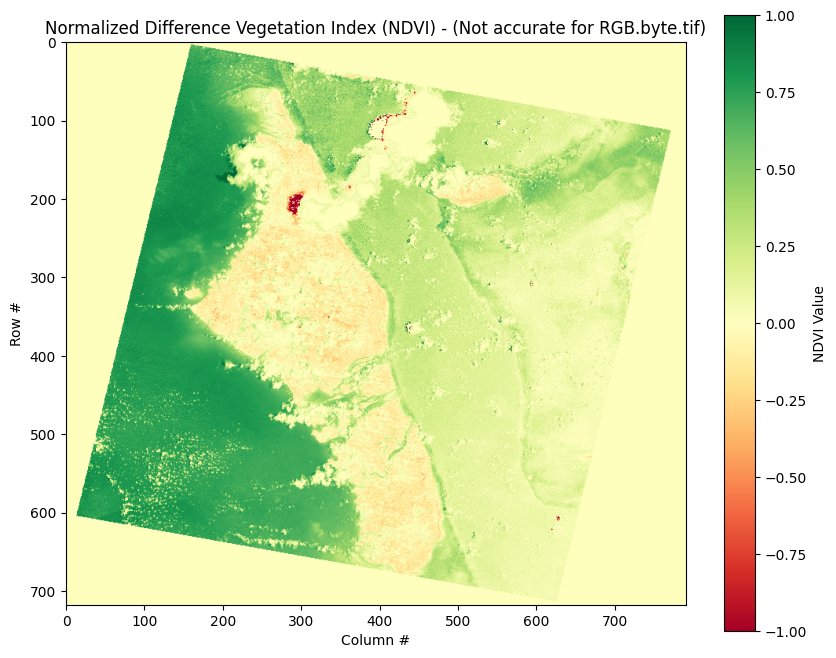

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import rasterio

raster_path = "RGB.byte.tif"

with rasterio.open(raster_path) as dataset:
    # สำหรับ RGB.byte.tif: Band 1 = Red, Band 2 = Green, Band 3 = Blue
    # ในการสาธิตนี้ เราจะสมมติว่า Band 1 เป็น Red และ Band 3 (Blue) เป็น NIR
    # ย้ำอีกครั้งว่านี่ไม่ใช่การคำนวณ NDVI ที่ถูกต้องตามหลักการทางภูมิสารสนเทศ
    red = dataset.read(1).astype(float)  # Band 1 เป็น Red
    nir = dataset.read(3).astype(float)  # ใช้ Band 3 (Blue) เป็น NIR สำหรับการสาธิต

# คำนวณ NDVI
# เพิ่มค่าคงที่เล็กน้อย (1e-10) เพื่อหลีกเลี่ยงการหารด้วยศูนย์
ndvi = (nir - red) / (nir + red + 1e-10)

# แสดงผล NDVI
plt.figure(figsize=(10, 8))
plt.imshow(ndvi, cmap="RdYlGn", vmin=-1, vmax=1) # ใช้ RdYlGn (แดง-เหลือง-เขียว) เพื่อแสดงค่า NDVI
plt.colorbar(label="NDVI Value")
plt.title("Normalized Difference Vegetation Index (NDVI) - (Not accurate for RGB.byte.tif)")
plt.xlabel("Column #")
plt.ylabel("Row #")
plt.show()


แบบฝึกหัด 4: ใช้ Rasterio ตัดข้อมูลภาพจากขอบเขตที่กำหนดในไฟล์ Shapefile

In [32]:
from rasterio.mask import mask
import geopandas as gpd # ยังคง import ไว้เผื่อต้องการใช้ในอนาคต แม้จะไม่ได้ใช้โหลดไฟล์
from shapely.geometry import box, mapping

# เปิดไฟล์ Raster เพื่อเข้าถึงข้อมูลเมตาและ transform
with rasterio.open(raster_path) as src:
    # ดึงขอบเขตของ Raster ในพิกัด CRS ของ Raster
    left, bottom, right, top = src.bounds
    crs = src.crs

# กำหนดขอบเขตใหม่สำหรับการตัด (ตัวอย่าง: ครึ่งหนึ่งของ Raster) ในพิกัดเดียวกันกับ Raster
# เพื่อให้มั่นใจว่าขอบเขตนี้จะทับซ้อนกับ Raster ตัวอย่าง
clip_left = left + (right - left) * 0.25
clip_bottom = bottom + (top - bottom) * 0.25
clip_right = right - (right - left) * 0.25
clip_top = top - (top - bottom) * 0.25

# สร้าง geometry แบบ Polygon จากขอบเขตที่กำหนด
clip_geometry = [mapping(box(clip_left, clip_bottom, clip_right, clip_top))]

# ตัดภาพ Raster
with rasterio.open(raster_path) as src:
    # ตรวจสอบว่า CRS ของ Raster และ Geometry ตรงกันหรือไม่
    # ในกรณีนี้ geometry ถูกสร้างขึ้นจาก bounds และ CRS ของ src จึงรับประกันว่าตรงกัน
    out_image, out_transform = mask(src, clip_geometry, crop=True)
    out_meta = src.meta.copy()

# อัปเดตเมตาดาต้าใหม่
out_meta.update({"height": out_image.shape[1],
                 "width": out_image.shape[2],
                 "transform": out_transform,
                 "nodata": 0,
                 "crs": crs}) # ใช้ CRS เดิมของ Raster

# บันทึกไฟล์ที่ถูกตัด
clipped_raster = "clipped_output_exercise.tif"
with rasterio.open(clipped_raster, "w", **out_meta) as dest:
    dest.write(out_image)

print(f"ตัดข้อมูล Raster สำเร็จ! บันทึกเป็น {clipped_raster}")

ตัดข้อมูล Raster สำเร็จ! บันทึกเป็น clipped_output_exercise.tif
